# Konut Fiyatları — Doğrusal Regresyon

**Veri:** Housing.csv (545 konut, 13 değişken)
**Hedef:** `price`

## 1. Veriyi Yükleme ve Keşif

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
sns.set_style('whitegrid')

import warnings
warnings.filterwarnings('ignore')

In [2]:
# CSV dosyasını oku
df = pd.read_csv('Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
# Sütun isimlerini ve veri tiplerini incele
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [4]:
# İstatistiksel özet
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,545.0,4.766729e+06,1.870440e+06,1750000.0,3430000.0,4340000.0,5740000.0,13300000.0
area,545.0,5.150541e+03,2.170141e+03,1650.0,3600.0,4600.0,6360.0,16200.0
bedrooms,545.0,2.965138e+00,7.380639e-01,1.0,2.0,3.0,3.0,6.0
bathrooms,545.0,1.286239e+00,5.024696e-01,1.0,1.0,1.0,2.0,4.0
stories,545.0,1.805505e+00,8.674925e-01,1.0,1.0,2.0,2.0,4.0
parking,545.0,6.935780e-01,8.615858e-01,0.0,0.0,0.0,1.0,3.0


### Değişken Sözlüğü

| Sütun | Anlamı | Tür |
|---|---|---|
| `price` | Konut fiyatı | Sürekli → **HEDEF** |
| `area` | Arsa/kullanım alanı (ft²) | Sürekli |
| `bedrooms` | Yatak odası sayısı | Sayısal |
| `bathrooms` | Banyo sayısı | Sayısal |
| `stories` | Kat sayısı | Sayısal |
| `mainroad` | Ana yola cepheli mi | İkili (yes/no) |
| `guestroom` | Misafir odası var mı | İkili (yes/no) |
| `basement` | Bodrum katı var mı | İkili (yes/no) |
| `hotwaterheating` | Sıcak su ısıtma sistemi | İkili (yes/no) |
| `airconditioning` | Klima var mı | İkili (yes/no) |
| `parking` | Otopark kapasitesi | Sayısal (0–3) |
| `prefarea` | Tercih edilen bölgede mi | İkili (yes/no) |
| `furnishingstatus` | Eşya durumu | Kategorik (3 seviye) |

## 2. Veri Temizliği ve Kodlama

In [5]:
# Eksik değer ve duplike kontrolü
print('Veri boyutu:', df.shape)
print('\nEksik değerler:')
print(df.isnull().sum().to_string())
print(f'\nToplam eksik değer: {df.isnull().sum().sum()}')
print(f'Tekrar eden satır sayısı: {df.duplicated().sum()}')

Veri boyutu: (545, 13)

Eksik değerler:
price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0

Toplam eksik değer: 0
Tekrar eden satır sayısı: 0


In [6]:
# Mantıksız değer kontrolü
print('Sayısal değişkenlerin sınırları:')
for col in ['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking']:
    print(f'  {col:<12}: min={df[col].min():>10,} | max={df[col].max():>12,} | sıfır sayısı={(df[col] == 0).sum()}')

print('\nKategorik değişkenlerin seviyeleri:')
for col in df.select_dtypes(include=['object']).columns:
    print(f'  {col:<20}: {df[col].unique().tolist()}')

Sayısal değişkenlerin sınırları:
  price       : min= 1,750,000 | max=  13,300,000 | sıfır sayısı=0
  area        : min=     1,650 | max=      16,200 | sıfır sayısı=0
  bedrooms    : min=         1 | max=           6 | sıfır sayısı=0
  bathrooms   : min=         1 | max=           4 | sıfır sayısı=0
  stories     : min=         1 | max=           4 | sıfır sayısı=0
  parking     : min=         0 | max=           3 | sıfır sayısı=299

Kategorik değişkenlerin seviyeleri:
  mainroad            : ['yes', 'no']
  guestroom           : ['no', 'yes']
  basement            : ['no', 'yes']
  hotwaterheating     : ['no', 'yes']
  airconditioning     : ['yes', 'no']
  prefarea            : ['yes', 'no']
  furnishingstatus    : ['furnished', 'semi-furnished', 'unfurnished']


### 2.1 Kategorik Değişkenlerin Kodlanması

İkili değişkenler 1/0'a çevriliyor, `furnishingstatus` için `drop_first=True` ile one-hot uygulanıyor.

In [7]:
# 1. İkili değişkenleri 1/0'a çevir
ikili_kolonlar = ['mainroad', 'guestroom', 'basement',
                  'hotwaterheating', 'airconditioning', 'prefarea']

for col in ikili_kolonlar:
    df[col] = (df[col] == 'yes').astype(int)

# 2. furnishingstatus için one-hot encoding
print(f"furnishingstatus dağılımı:")
print(df['furnishingstatus'].value_counts().to_string())

kuklalar = pd.get_dummies(df['furnishingstatus'], prefix='furnish', drop_first=True).astype(int)
df = pd.concat([df, kuklalar], axis=1).drop(columns=['furnishingstatus'])

print(f"\nOluşturulan kukla sütunlar: {kuklalar.columns.tolist()}")
print(f"Referans kategori (dışarıda bırakılan): 'furnished'")
print(f"\nTemizlik sonrası veri boyutu: {df.shape}")
df.head()

furnishingstatus dağılımı:
furnishingstatus
semi-furnished    227
unfurnished       178
furnished         140

Oluşturulan kukla sütunlar: ['furnish_semi-furnished', 'furnish_unfurnished']
Referans kategori (dışarıda bırakılan): 'furnished'

Temizlik sonrası veri boyutu: (545, 14)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnish_semi-furnished,furnish_unfurnished
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,0,0
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,0,0
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,0,0
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,0,0


## 3. Keşifçi Veri Analizi (EDA)

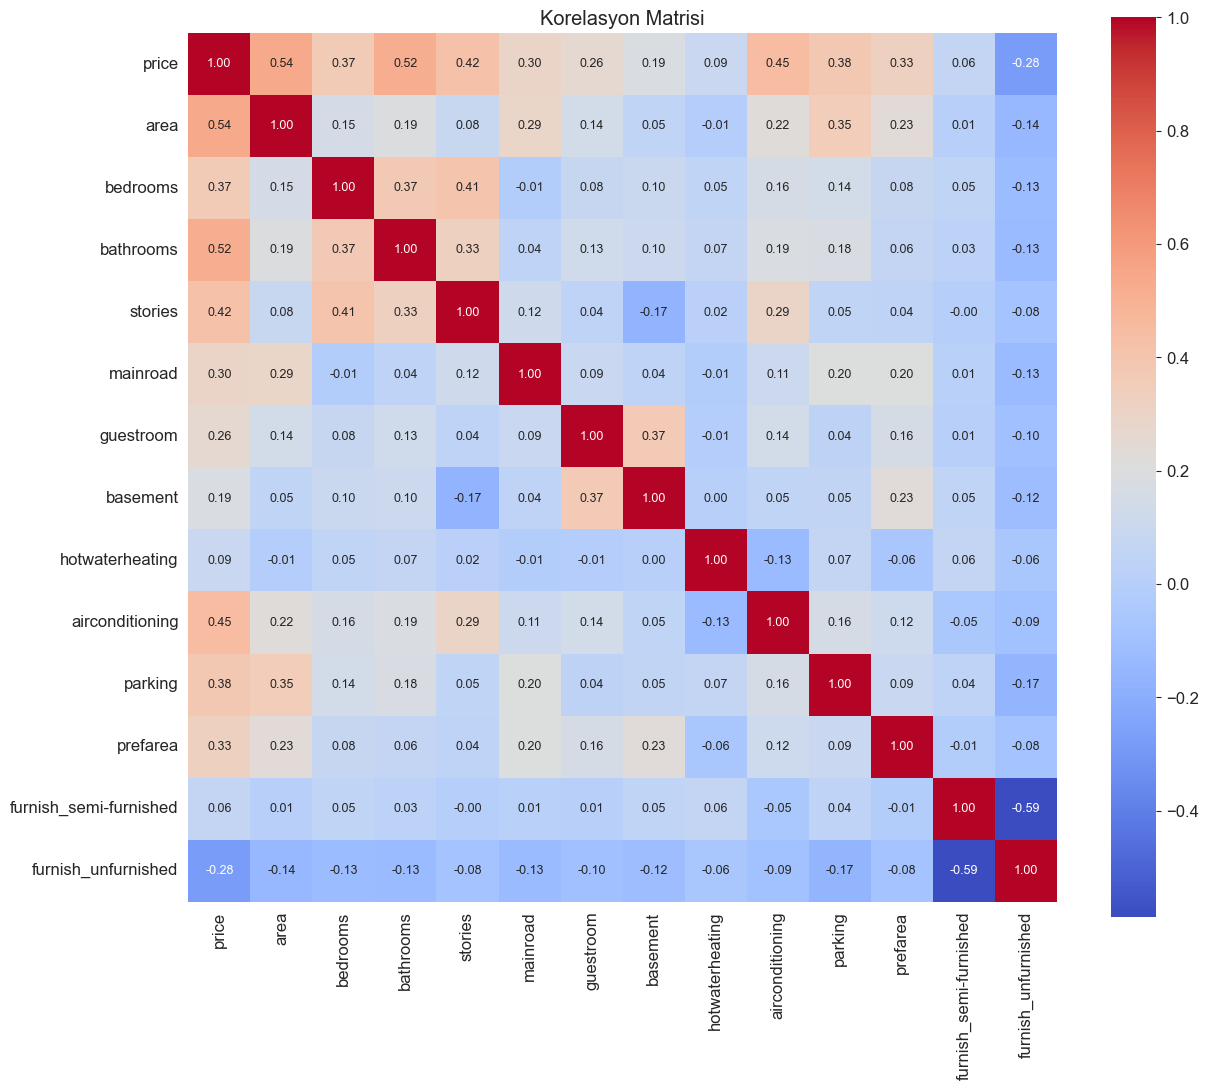

In [8]:
# Korelasyon matrisi
plt.figure(figsize=(13, 11))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True,
            annot_kws={'size': 9})
plt.title('Korelasyon Matrisi')
plt.tight_layout()
plt.show()

In [9]:
# Hedef değişken price ile en yüksek korelasyonlu değişkenler
target = 'price'
corr_with_target = corr[target].sort_values(ascending=False)
print('price ile Korelasyonlar:')
print(corr_with_target.to_string())

print('\nEn yüksek 5 pozitif korelasyon:')
print(corr_with_target[1:6].to_string())

price ile Korelasyonlar:
price                     1.000000
area                      0.535997
bathrooms                 0.517545
airconditioning           0.452954
stories                   0.420712
parking                   0.384394
bedrooms                  0.366494
prefarea                  0.329777
mainroad                  0.296898
guestroom                 0.255517
basement                  0.187057
hotwaterheating           0.093073
furnish_semi-furnished    0.063656
furnish_unfurnished      -0.280587

En yüksek 5 pozitif korelasyon:
area               0.535997
bathrooms          0.517545
airconditioning    0.452954
stories            0.420712
parking            0.384394


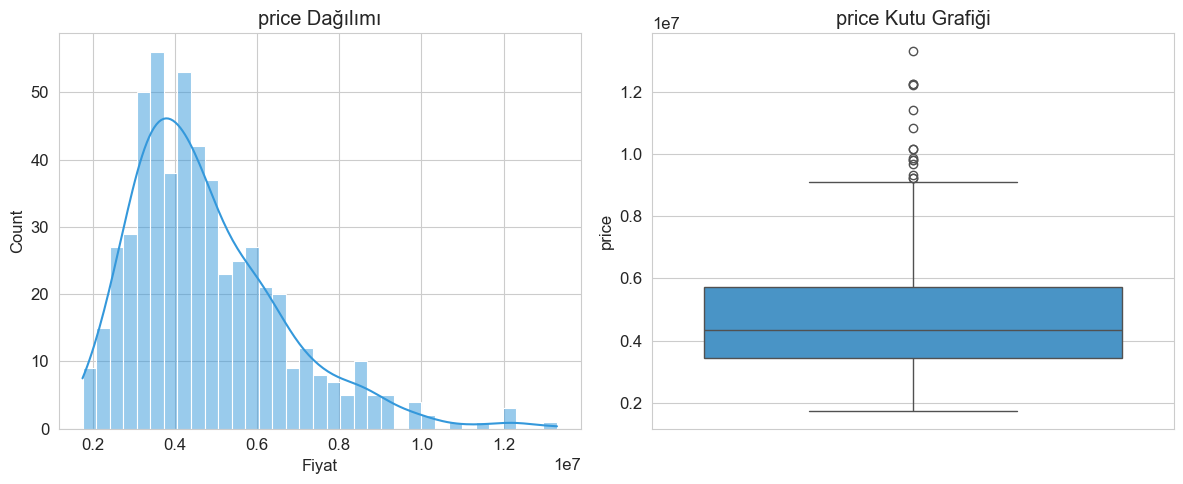

Ortalama: 4,766,729 | Medyan: 4,340,000
Çarpıklık (skewness): 1.209

Ortalama medyandan yüksek ve çarpıklık pozitif → dağılım SAĞA ÇARPIK.
Az sayıda çok pahalı konut ortalamayı yukarı çekiyor. Bölüm 6'da bunu ele alacağız.


In [10]:
# price dağılımı
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df[target], bins=35, kde=True, color='#3498db')
plt.title(f'{target} Dağılımı')
plt.xlabel('Fiyat')

plt.subplot(1, 2, 2)
sns.boxplot(y=df[target], color='#3498db')
plt.title(f'{target} Kutu Grafiği')
plt.tight_layout()
plt.show()

from scipy.stats import skew
print(f'Ortalama: {df[target].mean():,.0f} | Medyan: {df[target].median():,.0f}')
print(f'Çarpıklık (skewness): {skew(df[target]):.3f}')
print('\nOrtalama medyandan yüksek ve çarpıklık pozitif → dağılım SAĞA ÇARPIK.')
print('Az sayıda çok pahalı konut ortalamayı yukarı çekiyor. Bölüm 6\'da bunu ele alacağız.')

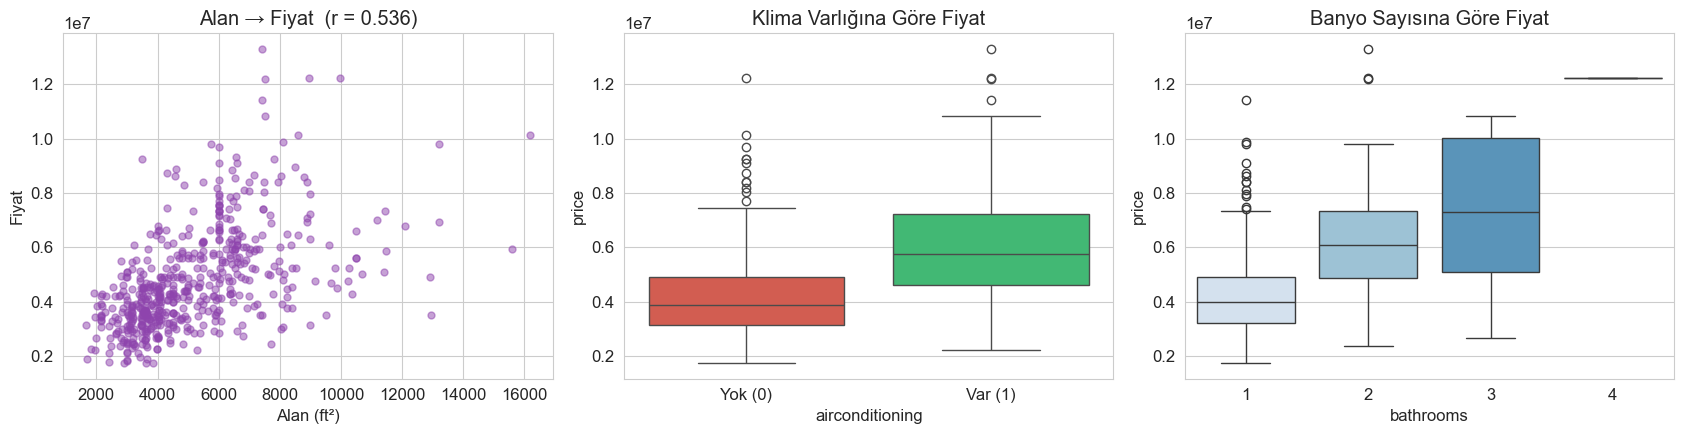

Medyan fiyat — klimalı: 5,757,500 | klimasız: 3,885,000 (1.48 kat)


In [11]:
# Alan - fiyat ilişkisi ve kategorik değişkenlerin etkisi
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].scatter(df['area'], df['price'], alpha=0.5, s=25, color='#8e44ad')
axes[0].set_xlabel('Alan (ft²)'); axes[0].set_ylabel('Fiyat')
axes[0].set_title(f'Alan → Fiyat  (r = {df["area"].corr(df["price"]):.3f})')

sns.boxplot(x='airconditioning', y='price', data=df, ax=axes[1], palette=['#e74c3c', '#2ecc71'])
axes[1].set_title('Klima Varlığına Göre Fiyat')
axes[1].set_xticklabels(['Yok (0)', 'Var (1)'])

sns.boxplot(x='bathrooms', y='price', data=df, ax=axes[2], palette='Blues')
axes[2].set_title('Banyo Sayısına Göre Fiyat')

plt.tight_layout()
plt.show()

klimali = df[df.airconditioning == 1]['price'].median()
klimasiz = df[df.airconditioning == 0]['price'].median()
print(f'Medyan fiyat — klimalı: {klimali:,.0f} | klimasız: {klimasiz:,.0f} ({klimali/klimasiz:.2f} kat)')

## 4. Basit Doğrusal Regresyon

### 4.1 Alan → Fiyat

`area`, fiyatla en yüksek korelasyona sahip değişken (r ≈ 0.54).

In [12]:
# Basit regresyon için değişkenler
X_simple = df[['area']].values
y = df['price'].values

# Eğitim ve test setlerine ayır (%80 eğitim, %20 test)
X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

print(f'Eğitim seti boyutu: {X_train.shape[0]}')
print(f'Test seti boyutu: {X_test.shape[0]}')

Eğitim seti boyutu: 436
Test seti boyutu: 109


In [13]:
# Modeli oluştur ve eğit
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Tahmin yap
y_pred_train = model_simple.predict(X_train)
y_pred_test = model_simple.predict(X_test)

# Model parametreleri
beta_0 = model_simple.intercept_
beta_1 = model_simple.coef_[0]

print(f'Kesim Noktası (β₀): {beta_0:,.4f}')
print(f'Eğim (β₁): {beta_1:.4f}')
print('\nModel Denklemi:')
print(f'price = {beta_0:,.2f} + {beta_1:.2f} × area')
print(f'\nYorum: Alan 1 ft² arttığında fiyat ortalama {beta_1:,.0f} birim artıyor.')
print(f'       100 ft² fazla alan ≈ {beta_1*100:,.0f} birim fiyat farkı.')

Kesim Noktası (β₀): 2,512,254.2640
Eğim (β₁): 425.7298

Model Denklemi:
price = 2,512,254.26 + 425.73 × area

Yorum: Alan 1 ft² arttığında fiyat ortalama 426 birim artıyor.
       100 ft² fazla alan ≈ 42,573 birim fiyat farkı.


In [14]:
# Tahmin vs gerçek değerler (test setinden ilk 10 gözlem)
results = pd.DataFrame({
    'Alan': X_test.flatten(),
    'Gerçek Fiyat': y_test,
    'Tahmin Edilen Fiyat': y_pred_test.round(0),
    'Fark (Artık)': (y_test - y_pred_test).round(0)
})
print('Test Seti Tahminleri (ilk 10):')
print(results.head(10).to_string(index=False))

Test Seti Tahminleri (ilk 10):
 Alan  Gerçek Fiyat  Tahmin Edilen Fiyat  Fark (Artık)
 5900       4060000            5024060.0     -964060.0
 6500       6650000            5279498.0     1370502.0
 4040       3710000            4232203.0     -522203.0
 5000       6440000            4640903.0     1799097.0
 3960       2800000            4198144.0    -1398144.0
 6720       4900000            5373159.0     -473159.0
 8520       5250000            6139473.0     -889473.0
 4990       4543000            4636646.0      -93646.0
 3240       2450000            3891619.0    -1441619.0
 2700       3353000            3661725.0     -308725.0


In [15]:
# Model performans metrikleri
rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_train = mean_absolute_error(y_train, y_pred_train)
mae_test = mean_absolute_error(y_test, y_pred_test)
r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred_test)

metrics = pd.DataFrame({
    'Metrik': ['RMSE', 'MAE', 'R²'],
    'Eğitim': [f'{rmse_train:,.0f}', f'{mae_train:,.0f}', f'{r2_train:.3f}'],
    'Test': [f'{rmse_test:,.0f}', f'{mae_test:,.0f}', f'{r2_test:.3f}']
})
print('Model Performansı:')
print(metrics.to_string(index=False))
print(f'\nR² = {r2_test:.3f} → Alan tek başına fiyattaki değişkenliğin sadece')
print(f'%{r2_test*100:.0f} kadarını açıklıyor. Geri kalan %{(1-r2_test)*100:.0f} başka faktörlerden geliyor.')

Model Performansı:
Metrik    Eğitim      Test
  RMSE 1,484,836 1,917,104
   MAE 1,092,586 1,474,748
    R²     0.285     0.273

R² = 0.273 → Alan tek başına fiyattaki değişkenliğin sadece
%27 kadarını açıklıyor. Geri kalan %73 başka faktörlerden geliyor.


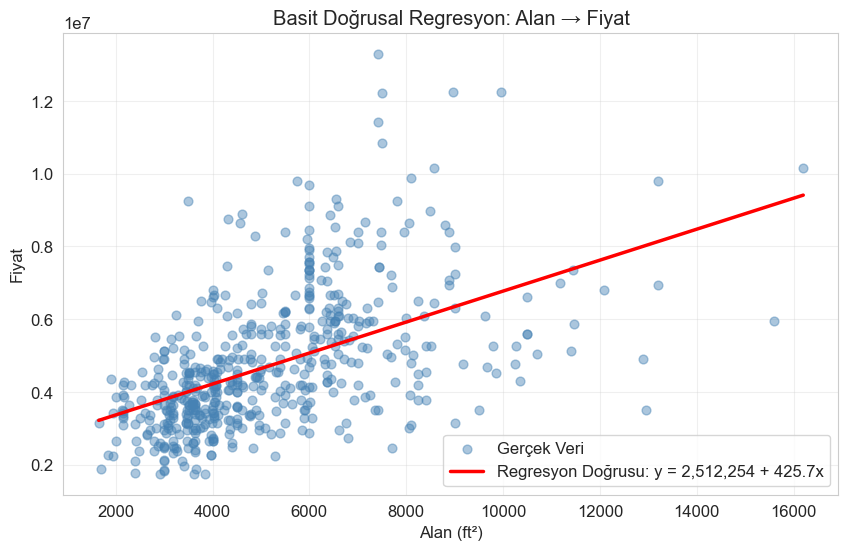

Dikkat: Noktalar doğrunun etrafında geniş bir bulut oluşturuyor.
Aynı alana sahip konutlar çok farklı fiyatlara sahip — tek değişken yetersiz.


In [16]:
# Görselleştirme: Regresyon doğrusu
plt.figure(figsize=(10, 6))

plt.scatter(X_simple, y, color='steelblue', alpha=0.45, label='Gerçek Veri', s=40)

x_line = np.linspace(X_simple.min(), X_simple.max(), 100).reshape(-1, 1)
y_line = model_simple.predict(x_line)
plt.plot(x_line, y_line, color='red', linewidth=2.5,
         label=f'Regresyon Doğrusu: y = {beta_0:,.0f} + {beta_1:.1f}x')

plt.xlabel('Alan (ft²)')
plt.ylabel('Fiyat')
plt.title('Basit Doğrusal Regresyon: Alan → Fiyat')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print('Dikkat: Noktalar doğrunun etrafında geniş bir bulut oluşturuyor.')
print('Aynı alana sahip konutlar çok farklı fiyatlara sahip — tek değişken yetersiz.')

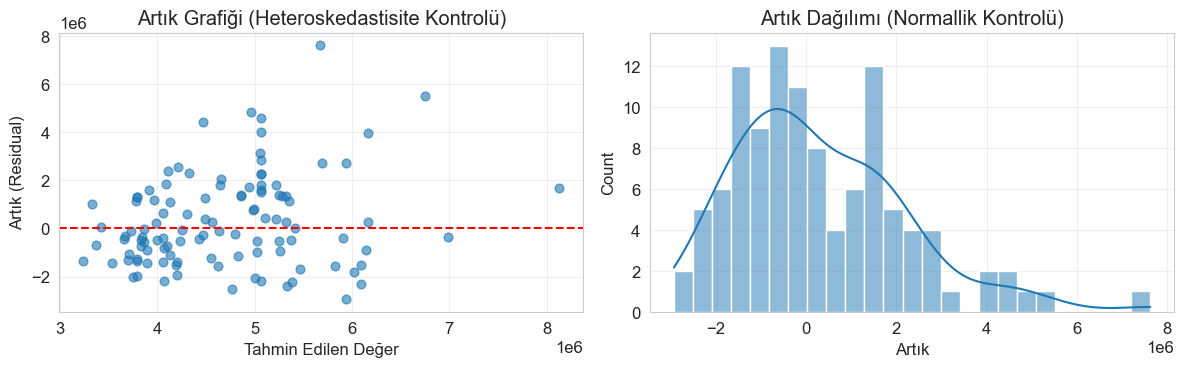

Artıkların ortalaması: 308,679.28
Artıkların standart sapması: 1,892,089.77

Sol grafikte artıkların yayılımı tahmin değeri arttıkça genişliyor →
heteroskedastisite belirtisi. Bu, sağa çarpık hedef değişkenin tipik sonucudur.


In [17]:
# Artık (Residual) analizi
residuals = y_test - y_pred_test

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test, residuals, alpha=0.6, s=40)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Artık (Residual)')
plt.title('Artık Grafiği (Heteroskedastisite Kontrolü)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals, bins=25, kde=True)
plt.xlabel('Artık')
plt.title('Artık Dağılımı (Normallik Kontrolü)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Artıkların ortalaması: {np.mean(residuals):,.2f}')
print(f'Artıkların standart sapması: {np.std(residuals):,.2f}')
print('\nSol grafikte artıkların yayılımı tahmin değeri arttıkça genişliyor →')
print('heteroskedastisite belirtisi. Bu, sağa çarpık hedef değişkenin tipik sonucudur.')

## 5. Çoklu Doğrusal Regresyon

### 5.1 Özellik Seçimi ve Çoklu Bağlantı Kontrolü

In [18]:
# Tüm özellikleri kullanıyoruz (hedef hariç)
selected_features = [c for c in df.columns if c != 'price']

available_features = [f for f in selected_features if f in df.columns]
print(f'Kullanılacak özellikler ({len(available_features)} adet):')
for f in available_features:
    print(f'  {f:<24} (price ile korelasyon: {df[f].corr(df["price"]):+.3f})')

Kullanılacak özellikler (13 adet):
  area                     (price ile korelasyon: +0.536)
  bedrooms                 (price ile korelasyon: +0.366)
  bathrooms                (price ile korelasyon: +0.518)
  stories                  (price ile korelasyon: +0.421)
  mainroad                 (price ile korelasyon: +0.297)
  guestroom                (price ile korelasyon: +0.256)
  basement                 (price ile korelasyon: +0.187)
  hotwaterheating          (price ile korelasyon: +0.093)
  airconditioning          (price ile korelasyon: +0.453)
  parking                  (price ile korelasyon: +0.384)
  prefarea                 (price ile korelasyon: +0.330)
  furnish_semi-furnished   (price ile korelasyon: +0.064)
  furnish_unfurnished      (price ile korelasyon: -0.281)


In [19]:
# Çoklu bağlantı (multicollinearity) kontrolü - VIF hesabı
X_all = df[available_features].values

print('VIF Değerleri:')
vif_listesi = []
for i, feat in enumerate(available_features):
    X_others = np.delete(X_all, i, axis=1)
    y_current = X_all[:, i]
    r2_i = LinearRegression().fit(X_others, y_current).score(X_others, y_current)
    vif = 1 / (1 - r2_i)
    vif_listesi.append(vif)
    durum = 'OK' if vif < 5 else ('DİKKAT' if vif < 10 else 'SORUNLU')
    print(f'  {feat:<24}: {vif:>6.2f}  [{durum}]')

print(f'\nEn yüksek VIF: {max(vif_listesi):.2f} → tüm değerler 5\'in çok altında.')
print('Ciddi bir çoklu bağlantı sorunu YOK, tüm özellikler modelde tutulabilir.')

VIF Değerleri:
  area                    :   1.33  [OK]
  bedrooms                :   1.37  [OK]
  bathrooms               :   1.29  [OK]
  stories                 :   1.48  [OK]
  mainroad                :   1.17  [OK]
  guestroom               :   1.21  [OK]
  basement                :   1.32  [OK]
  hotwaterheating         :   1.04  [OK]
  airconditioning         :   1.21  [OK]
  parking                 :   1.21  [OK]
  prefarea                :   1.15  [OK]
  furnish_semi-furnished  :   1.58  [OK]
  furnish_unfurnished     :   1.67  [OK]

En yüksek VIF: 1.67 → tüm değerler 5'in çok altında.
Ciddi bir çoklu bağlantı sorunu YOK, tüm özellikler modelde tutulabilir.


### 5.2 Model Kurulumu ve Eğitim

In [20]:
# Çoklu regresyon için veri hazırlığı
X_multi = df[available_features].values
y_multi = df['price'].values

# Eğitim ve test setlerine ayır
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_multi, y_multi, test_size=0.2, random_state=42
)

print(f'Eğitim seti: {X_train_m.shape}')
print(f'Test seti: {X_test_m.shape}')

Eğitim seti: (436, 13)
Test seti: (109, 13)


In [21]:
# Çoklu doğrusal regresyon modelini oluştur ve eğit
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train_m)

# Tahmin
y_pred_train_m = model_multi.predict(X_train_m)
y_pred_test_m = model_multi.predict(X_test_m)

# Model katsayıları
print('Kesim Noktası (Intercept):', f'{model_multi.intercept_:,.2f}')
print('\nKatsayılar:')
for feat, coef in zip(available_features, model_multi.coef_):
    print(f'  {feat:<24}: {coef:>15,.2f}')

Kesim Noktası (Intercept): 260,032.36

Katsayılar:
  area                    :          235.97
  bedrooms                :       76,778.70
  bathrooms               :    1,094,444.79
  stories                 :      407,476.59
  mainroad                :      367,919.95
  guestroom               :      231,610.04
  basement                :      390,251.18
  hotwaterheating         :      684,649.89
  airconditioning         :      791,426.74
  parking                 :      224,841.91
  prefarea                :      629,890.57
  furnish_semi-furnished  :     -126,881.82
  furnish_unfurnished     :     -413,645.06


In [22]:
# Katsayıların pratik yorumu
print('KATSAYI YORUMLARI (diğer her şey sabitken):')
print('─' * 62)
kat = dict(zip(available_features, model_multi.coef_))
print(f'  1 ft² fazla alan            : {kat["area"]:>12,.0f} birim fiyat artışı')
print(f'  1 banyo daha                : {kat["bathrooms"]:>12,.0f} birim fiyat artışı')
print(f'  1 kat daha                  : {kat["stories"]:>12,.0f} birim fiyat artışı')
print(f'  Klima varlığı               : {kat["airconditioning"]:>12,.0f} birim fiyat artışı')
print(f'  Tercih edilen bölge         : {kat["prefarea"]:>12,.0f} birim fiyat artışı')
print(f'  Eşyasız (furnished\'a göre)  : {kat["furnish_unfurnished"]:>12,.0f} birim fiyat farkı')
print()
print(f'  1 yatak odası daha          : {kat["bedrooms"]:>12,.0f} birim')
print('  ↑ Dikkat: yatak odası katsayısı banyo katsayısının çok altında.')
print('    Ham korelasyonu 0.37 olmasına rağmen, alan ve banyo modele girince')
print('    yatak odasının bağımsız katkısı büyük ölçüde eriyor.')

KATSAYI YORUMLARI (diğer her şey sabitken):
──────────────────────────────────────────────────────────────
  1 ft² fazla alan            :          236 birim fiyat artışı
  1 banyo daha                :    1,094,445 birim fiyat artışı
  1 kat daha                  :      407,477 birim fiyat artışı
  Klima varlığı               :      791,427 birim fiyat artışı
  Tercih edilen bölge         :      629,891 birim fiyat artışı
  Eşyasız (furnished'a göre)  :     -413,645 birim fiyat farkı

  1 yatak odası daha          :       76,779 birim
  ↑ Dikkat: yatak odası katsayısı banyo katsayısının çok altında.
    Ham korelasyonu 0.37 olmasına rağmen, alan ve banyo modele girince
    yatak odasının bağımsız katkısı büyük ölçüde eriyor.


In [23]:
# Model performansı
rmse_train_m = np.sqrt(mean_squared_error(y_train_m, y_pred_train_m))
rmse_test_m = np.sqrt(mean_squared_error(y_test_m, y_pred_test_m))
mae_train_m = mean_absolute_error(y_train_m, y_pred_train_m)
mae_test_m = mean_absolute_error(y_test_m, y_pred_test_m)
r2_train_m = r2_score(y_train_m, y_pred_train_m)
r2_test_m = r2_score(y_test_m, y_pred_test_m)

metrics_multi = pd.DataFrame({
    'Metrik': ['RMSE', 'MAE', 'R²'],
    'Eğitim': [f'{rmse_train_m:,.0f}', f'{mae_train_m:,.0f}', f'{r2_train_m:.3f}'],
    'Test': [f'{rmse_test_m:,.0f}', f'{mae_test_m:,.0f}', f'{r2_test_m:.3f}']
})
print('Çoklu Regresyon Model Performansı:')
print(metrics_multi.to_string(index=False))

Çoklu Regresyon Model Performansı:
Metrik  Eğitim      Test
  RMSE 984,052 1,324,507
   MAE 719,243   970,043
    R²   0.686     0.653


In [24]:
# İki modeli karşılaştır (Test seti üzerinden)
comparison = pd.DataFrame({
    'Model': ['Basit Regresyon (area)', 'Çoklu Regresyon'],
    'RMSE': [f'{rmse_test:,.0f}', f'{rmse_test_m:,.0f}'],
    'MAE': [f'{mae_test:,.0f}', f'{mae_test_m:,.0f}'],
    'R²': [f'{r2_test:.3f}', f'{r2_test_m:.3f}']
})
print('Model Karşılaştırması (Test Seti):')
print(comparison.to_string(index=False))

print(f'\nR² artışı: {r2_test_m - r2_test:+.3f}')
print(f'RMSE azalışı: {rmse_test - rmse_test_m:,.0f} birim (%{(1-rmse_test_m/rmse_test)*100:.1f} iyileşme)')

Model Karşılaştırması (Test Seti):
                 Model      RMSE       MAE    R²
Basit Regresyon (area) 1,917,104 1,474,748 0.273
       Çoklu Regresyon 1,324,507   970,043 0.653

R² artışı: +0.380
RMSE azalışı: 592,597 birim (%30.9 iyileşme)


In [25]:
# 5-katlı çapraz doğrulama ile daha güvenilir karşılaştırma
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_basit = cross_val_score(LinearRegression(), X_simple, y, cv=kf, scoring='r2')
cv_coklu = cross_val_score(LinearRegression(), X_multi, y, cv=kf, scoring='r2')

print('5-Katlı Çapraz Doğrulama (R²):')
print(f'  Basit  : {cv_basit.mean():.4f} (± {cv_basit.std():.4f})')
print(f'  Çoklu  : {cv_coklu.mean():.4f} (± {cv_coklu.std():.4f})')
print('\nTek bölme yerine 5 farklı bölmenin ortalaması alındığı için bu sonuç')
print('şans faktöründen daha az etkilenir ve raporlanmaya daha uygundur.')

5-Katlı Çapraz Doğrulama (R²):
  Basit  : 0.2262 (± 0.1447)
  Çoklu  : 0.6324 (± 0.0737)

Tek bölme yerine 5 farklı bölmenin ortalaması alındığı için bu sonuç
şans faktöründen daha az etkilenir ve raporlanmaya daha uygundur.


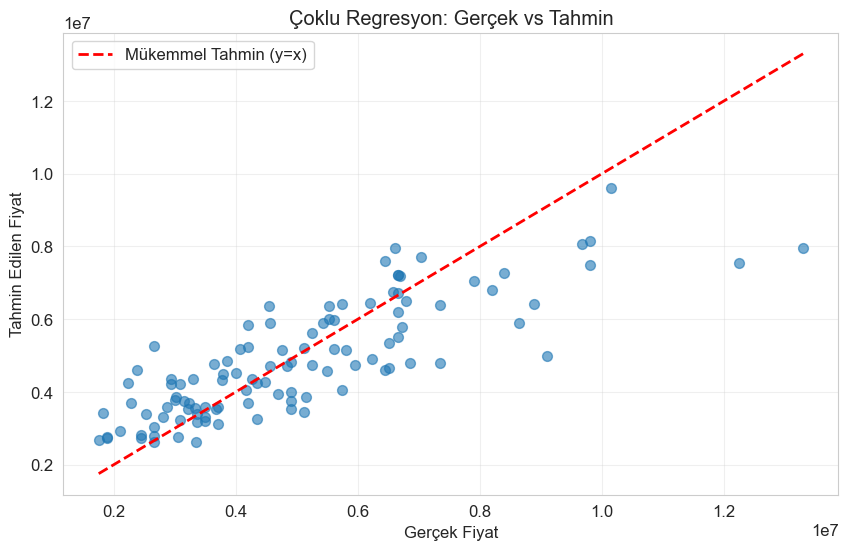

In [26]:
# Gerçek vs Tahmin karşılaştırması (Çoklu Regresyon)
plt.figure(figsize=(10, 6))
plt.scatter(y_test_m, y_pred_test_m, alpha=0.6, s=50)
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()],
         'r--', linewidth=2, label='Mükemmel Tahmin (y=x)')
plt.xlabel('Gerçek Fiyat')
plt.ylabel('Tahmin Edilen Fiyat')
plt.title('Çoklu Regresyon: Gerçek vs Tahmin')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

               Özellik  Ham Katsayı  Std Katsayı  |Std Katsayı|
furnish_semi-furnished    -126881.8     -22847.0        22847.0
              bedrooms      76778.7      84642.8        84642.8
             guestroom     231610.0     114950.3       114950.3
              mainroad     367919.9     146735.4       146735.4
              basement     390251.2     167040.8       167040.8
       hotwaterheating     684649.9     178965.1       178965.1
   furnish_unfurnished    -413645.1    -192857.2       192857.2
               parking     224841.9     238532.4       238532.4
              prefarea     629890.6     276197.7       276197.7
               stories     407476.6     390748.3       390748.3
       airconditioning     791426.7     401991.9       401991.9
             bathrooms    1094444.8     495817.7       495817.7
                  area        236.0     529330.6       529330.6


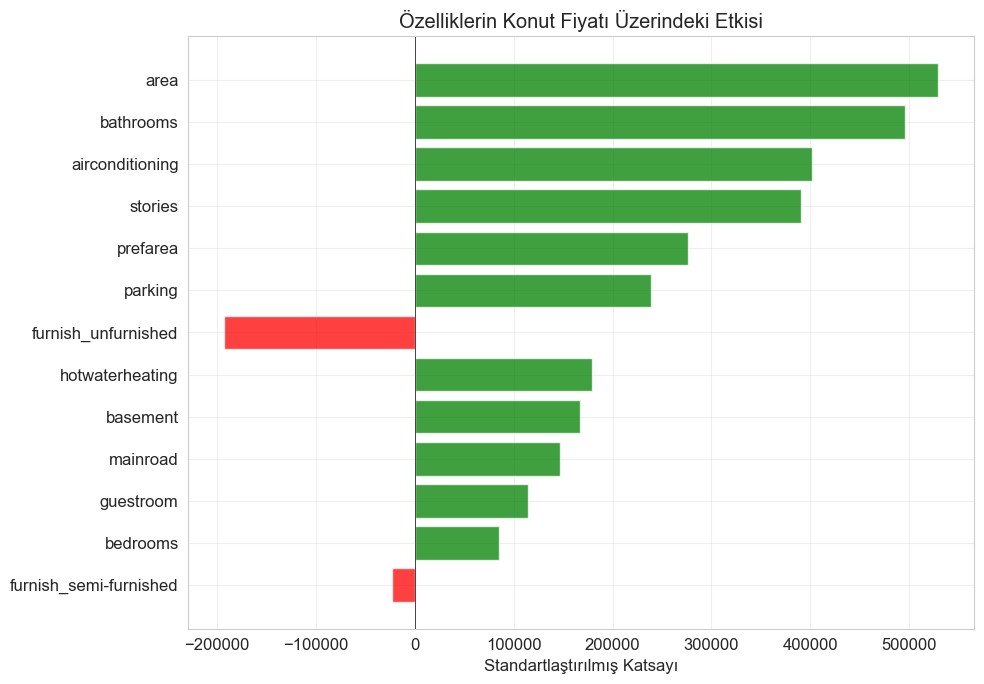


Standartlaştırılmış ölçekte area ve bathrooms başa güreşiyor;
ham katsayılarda area çok küçük görünüyordu (236) çünkü birimi 1 ft².


In [27]:
# Standartlaştırılmış katsayılar ile özellik önemi
# NOT: Ham katsayılar farklı birimlerde olduğu için doğrudan karşılaştırılamaz
#      (area ft² cinsinden, airconditioning 0/1). Bu yüzden önce standartlaştırıyoruz.
scaler = StandardScaler()
X_multi_scaled = scaler.fit_transform(X_multi)
model_std = LinearRegression().fit(X_multi_scaled, y_multi)

feature_importance = pd.DataFrame({
    'Özellik': available_features,
    'Ham Katsayı': model_multi.coef_,
    'Std Katsayı': model_std.coef_,
    '|Std Katsayı|': np.abs(model_std.coef_)
}).sort_values('|Std Katsayı|', ascending=True)

print(feature_importance.round(1).to_string(index=False))

plt.figure(figsize=(10, 7))
colors = ['green' if c > 0 else 'red' for c in feature_importance['Std Katsayı']]
plt.barh(feature_importance['Özellik'], feature_importance['Std Katsayı'], color=colors, alpha=0.75)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.xlabel('Standartlaştırılmış Katsayı')
plt.title('Özelliklerin Konut Fiyatı Üzerindeki Etkisi')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print('\nStandartlaştırılmış ölçekte area ve bathrooms başa güreşiyor;')
print('ham katsayılarda area çok küçük görünüyordu (236) çünkü birimi 1 ft².')

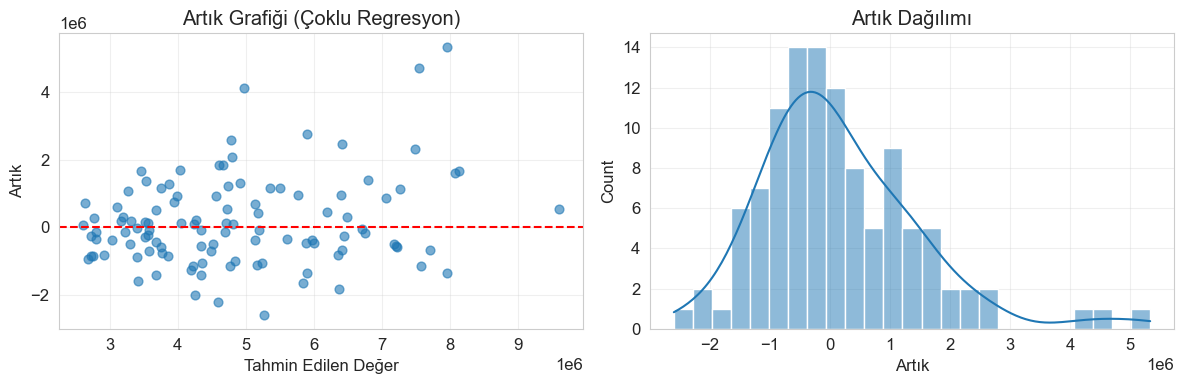

Artıkların ortalaması: 146,055.36
Artıkların standart sapması: 1,316,429.46


In [28]:
# Çoklu regresyon artık analizi
residuals_m = y_test_m - y_pred_test_m

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(y_pred_test_m, residuals_m, alpha=0.6, s=40)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Tahmin Edilen Değer')
plt.ylabel('Artık')
plt.title('Artık Grafiği (Çoklu Regresyon)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
sns.histplot(residuals_m, bins=25, kde=True)
plt.xlabel('Artık')
plt.title('Artık Dağılımı')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Artıkların ortalaması: {np.mean(residuals_m):,.2f}')
print(f'Artıkların standart sapması: {np.std(residuals_m):,.2f}')

## 6. Ek Analiz: Logaritmik Dönüşüm

Bölüm 3'te `price` dağılımının sağa çarpık, Bölüm 4'te artıkların yayılımının tahmin değeriyle genişlediği görüldü. Hedefin logaritması alınıp sonuçlar orijinal ölçeğe geri döndürülerek karşılaştırılıyor.

In [29]:
from scipy.stats import skew

# Log dönüşümünün çarpıklığa etkisi
print(f'price çarpıklığı        : {skew(y_multi):.3f}')
print(f'log(price) çarpıklığı   : {skew(np.log(y_multi)):.3f}')
print('→ Log dönüşümü dağılımı normale çok yaklaştırdı.\n')

# Log hedefli model
model_log = LinearRegression()
model_log.fit(X_train_m, np.log(y_train_m))

# Tahminleri orijinal ölçeğe geri döndür
y_pred_log = np.exp(model_log.predict(X_test_m))

r2_log = r2_score(y_test_m, y_pred_log)
rmse_log = np.sqrt(mean_squared_error(y_test_m, y_pred_log))
mae_log = mean_absolute_error(y_test_m, y_pred_log)

karsilastirma_log = pd.DataFrame({
    'Model': ['Çoklu Regresyon (ham fiyat)', 'Çoklu Regresyon (log fiyat)'],
    'R²': [f'{r2_test_m:.3f}', f'{r2_log:.3f}'],
    'RMSE': [f'{rmse_test_m:,.0f}', f'{rmse_log:,.0f}'],
    'MAE': [f'{mae_test_m:,.0f}', f'{mae_log:,.0f}']
})
print(karsilastirma_log.to_string(index=False))

price çarpıklığı        : 1.209
log(price) çarpıklığı   : 0.140
→ Log dönüşümü dağılımı normale çok yaklaştırdı.

                      Model    R²      RMSE     MAE
Çoklu Regresyon (ham fiyat) 0.653 1,324,507 970,043
Çoklu Regresyon (log fiyat) 0.658 1,314,648 960,123


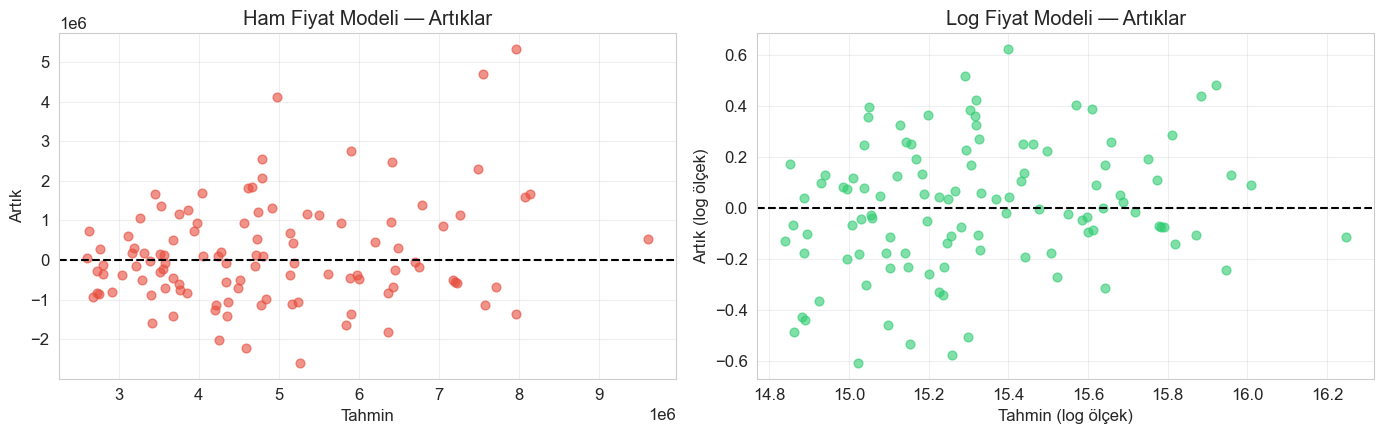

Sağdaki grafikte artıkların yayılımı çok daha homojen →
eşvaryanslılık varsayımı log modelde daha iyi karşılanıyor.
R² kazancı küçük olsa da model istatistiksel olarak daha savunulabilir.


In [30]:
# İki modelin artık dağılımlarının karşılaştırılması
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].scatter(y_pred_test_m, y_test_m - y_pred_test_m, alpha=0.6, s=40, color='#e74c3c')
axes[0].axhline(0, color='black', linestyle='--')
axes[0].set_xlabel('Tahmin'); axes[0].set_ylabel('Artık')
axes[0].set_title('Ham Fiyat Modeli — Artıklar')
axes[0].grid(alpha=0.3)

axes[1].scatter(model_log.predict(X_test_m), np.log(y_test_m) - model_log.predict(X_test_m),
                alpha=0.6, s=40, color='#2ecc71')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_xlabel('Tahmin (log ölçek)'); axes[1].set_ylabel('Artık (log ölçek)')
axes[1].set_title('Log Fiyat Modeli — Artıklar')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print('Sağdaki grafikte artıkların yayılımı çok daha homojen →')
print('eşvaryanslılık varsayımı log modelde daha iyi karşılanıyor.')
print('R² kazancı küçük olsa da model istatistiksel olarak daha savunulabilir.')

## 7. Bulgular

**Veri hazırlığı:** Eksik değer ve duplike yok. 6 ikili değişken 1/0'a çevrildi, `furnishingstatus` one-hot kodlandı.

**Basit regresyon (area → price):** Test R² 0.273. Alan tek başına fiyattaki değişkenliğin dörtte birini açıklıyor. Saçılım grafiğinde aynı alana sahip konutlar çok farklı fiyatlara sahip.

**Çoklu regresyon:** Test R² 0.653, 5-katlı CV R² 0.632. Tüm VIF değerleri 1.7'nin altında, çoklu bağlantı sorunu yok.

**`bedrooms` bulgusu:** Ham korelasyonu 0.37 olmasına rağmen standartlaştırılmış katsayısı 84 bin; `bathrooms` ise 495 bin. Yatak odasının etkisi büyük ölçüde alan üzerinden geliyor, alan kontrol edildiğinde bağımsız katkısı eriyor. Ham korelasyona bakarak özellik önemi çıkarmak yanıltıcı.

**Logaritmik dönüşüm:** Çarpıklık 1.21 → 0.14. Artıkların yayılımı belirgin şekilde homojenleşiyor, eşvaryanslılık varsayımı daha iyi karşılanıyor. R² kazancı küçük (0.653 → 0.658) ama model varsayımlar açısından daha sağlam.

**Modelin açıklayamadığı kısım:** Konum, bina yaşı, kat düzeyi gibi emlak fiyatını belirleyen kritik değişkenler veri setinde yok.

In [31]:
# Tüm modelleri özetle
print('=' * 62)
print('KONUT FİYATLARI - REGRESYON ANALİZİ ÖZETİ')
print('=' * 62)
print(f'Veri boyutu: {df.shape[0]} konut, {len(available_features)} özellik')

print('\n1. BASİT DOĞRUSAL REGRESYON')
print(f'   Hedef: price')
print(f'   Özellik: area')
print(f'   Denklem: price = {beta_0:,.2f} + {beta_1:.2f} × area')
print(f'   Test R²  : {r2_test:.3f}')
print(f'   Test RMSE: {rmse_test:,.0f}')
print(f'   Test MAE : {mae_test:,.0f}')

print('\n2. ÇOKLU DOĞRUSAL REGRESYON')
print(f'   Hedef: price')
print(f'   Özellik sayısı: {len(available_features)}')
print(f'   Test R²  : {r2_test_m:.3f}')
print(f'   Test RMSE: {rmse_test_m:,.0f}')
print(f'   Test MAE : {mae_test_m:,.0f}')
print(f'   En yüksek VIF: {max(vif_listesi):.2f} (çoklu bağlantı yok)')

print('\n3. LOG-HEDEFLİ ÇOKLU REGRESYON (ek analiz)')
print(f'   Test R²  : {r2_log:.3f}')
print(f'   Test RMSE: {rmse_log:,.0f}')
print(f'   Test MAE : {mae_log:,.0f}')

print('\n4. MODEL KARŞILAŞTIRMASI')
better_model = 'Çoklu Regresyon' if r2_test_m > r2_test else 'Basit Regresyon'
print(f'   R² değerine göre daha iyi model: {better_model}')
print(f'   R² artışı (basit → çoklu): {r2_test_m - r2_test:+.3f}')
print(f'   5-katlı CV R² (çoklu): {cv_coklu.mean():.4f}')
print('=' * 62)

KONUT FİYATLARI - REGRESYON ANALİZİ ÖZETİ
Veri boyutu: 545 konut, 13 özellik

1. BASİT DOĞRUSAL REGRESYON
   Hedef: price
   Özellik: area
   Denklem: price = 2,512,254.26 + 425.73 × area
   Test R²  : 0.273
   Test RMSE: 1,917,104
   Test MAE : 1,474,748

2. ÇOKLU DOĞRUSAL REGRESYON
   Hedef: price
   Özellik sayısı: 13
   Test R²  : 0.653
   Test RMSE: 1,324,507
   Test MAE : 970,043
   En yüksek VIF: 1.67 (çoklu bağlantı yok)

3. LOG-HEDEFLİ ÇOKLU REGRESYON (ek analiz)
   Test R²  : 0.658
   Test RMSE: 1,314,648
   Test MAE : 960,123

4. MODEL KARŞILAŞTIRMASI
   R² değerine göre daha iyi model: Çoklu Regresyon
   R² artışı (basit → çoklu): +0.380
   5-katlı CV R² (çoklu): 0.6324
